### Find latent features in Place cells using Matrioshka SAEs

Main goal: look at different levels of features in a 3-level MSAE

Steps:

1. Train MSAE on spikes dataset

2. Create (topk) sae feature df

3. Create stim (meta)data df

4. Interp / autointerp
    
    a. Create infra for finding stim at times of particular feature(s)
    
    b. Create infra for finding topk SAE features that fire at times of particular stim

In [ ]:
"""Import packages."""

import math
from collections import defaultdict
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Callable, List, Optional, Tuple
import os 

# import jax
import numpy as np
import pandas as pd
import seaborn as sns
import torch as t
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from einops import asnumpy, einsum, rearrange, reduce, repeat, pack, parse_shape, unpack
from einops.layers.torch import Rearrange, Reduce
from IPython.display import HTML
from jaxtyping import Float, Int
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from plotly import express as px
from plotly import graph_objects as go
from plotly.subplots import make_subplots
from rich import print as rprint
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from torch import bfloat16, nn, Tensor
from torch.nn import functional as F
from torcheval.metrics.functional import r2_score as tm_r2_score
from tqdm.notebook import tqdm


from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

from mini import train as mt
from mini.util import vec_r2

In [2]:
"""Set notebook settings."""

%load_ext autoreload
%autoreload 2
# %flow mode reactive

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 25)

In [3]:
# Choose dataset to use:

# options: "20Hz_4PCs_5Hz_96noise", "40Hz_4PCs_5Hz_96noise", "20Hz_4PCs_5Hz_32noise"
folder = "20Hz_10PCs_5Hz_10noise"

In [4]:
# Load simulated place cells spike matrix (this matrix has data from 4 simulated place cells and 96 random cells - aka noise)

spike_matrix = np.load("./" + folder + "/spike_matrix.npy")

print(spike_matrix.shape) 

# We want it the other way around, neurons = columns and rows = timepoints
spike_matrix = spike_matrix.T

print(spike_matrix.shape)

(20, 300000)
(300000, 20)


### Train MSAE

In [5]:
dsae_topk_map = {32: 1, 64: 2, 128: 4}
dsae_topk_map = dict(sorted(dsae_topk_map.items()))  # ensure sorted from smallest to largest
dsae_loss_x_map = {64: 1, 128: 1.25, 256: 1.5}
dsae_loss_x_map = dict(sorted(dsae_loss_x_map.items()))
dsae = max(dsae_topk_map.keys())
n_inst = 2
# gonna want a gpu if training! not necessary if loading saved features from a trained model
device = t.device("cuda" if t.cuda.is_available() else "cpu")
print(f"{device=}")

device=device(type='cuda')


In [6]:
# convert to torch tensor and normalize spike counts

spike_cts = t.from_numpy(spike_matrix).bfloat16().to(device)
#spike_cts /= spike_cts.max()

mean = spike_cts.mean(dim=0, keepdim=True)
std = spike_cts.std(dim=0, keepdim=True)
spike_cts = (spike_cts - mean) / (std) + 1e-8

In [9]:
sae_cfg = mt.SaeConfig(
    n_input_ae=spike_cts.shape[1],
    dsae_topk_map=dsae_topk_map,
    dsae_loss_x_map=dsae_loss_x_map,
    seq_len=1,
    n_instances=n_inst,
)
sae = mt.Sae(sae_cfg).to(device)
loss_fn = mt.msle
tau = 1.0
lr = 1e-3

n_epochs = 2
batch_sz = 16
n_steps = spike_cts.shape[0] // batch_sz * n_epochs
log_freq = n_steps // n_epochs // 2
dead_neuron_window = n_steps // n_epochs // 3

data_log = mt.optimize(  # train model
    spk_cts=spike_cts,
    sae=sae,
    loss_fn=loss_fn,
    optimizer=t.optim.Adam(sae.parameters(), lr=lr),
    use_lr_sched=True,
    dead_neuron_window=dead_neuron_window,
    n_steps=n_steps,
    log_freq=log_freq,
    batch_sz=batch_sz,
    log_wandb=False,
    plot_l0=False,
    tau=tau
)

SAE batch training step:   0%|          | 18/37500 [00:00<03:37, 172.59it/s, loss=0.24945,  l0_mean=4.0, l0_std=8.036208152770996, frac_dead=0.0]

SAE batch training step: 100%|██████████| 37500/37500 [03:34<00:00, 174.83it/s, loss=0.01773,  l0_mean=4.0, l0_std=1.0160009860992432, frac_dead=0.0]


## Validate SAEs

In [10]:
"""Check for nans in weights."""

sae.W_dec.isnan().sum(), sae.W_enc.isnan().sum()

(tensor(0, device='cuda:0'), tensor(0, device='cuda:0'))

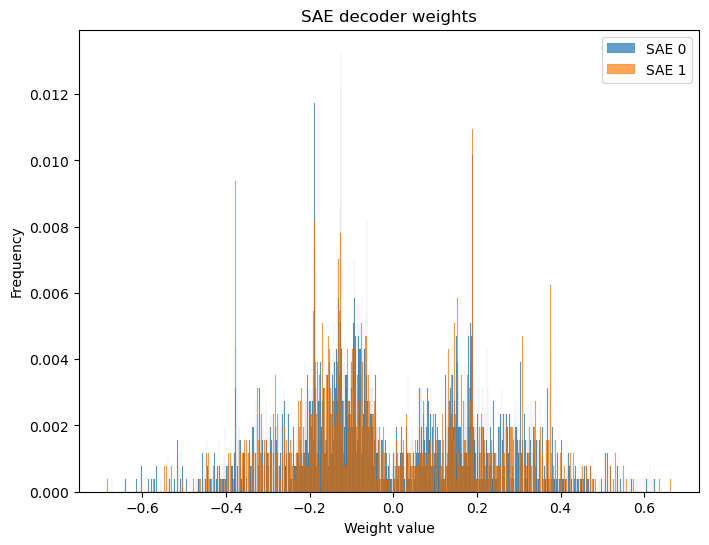

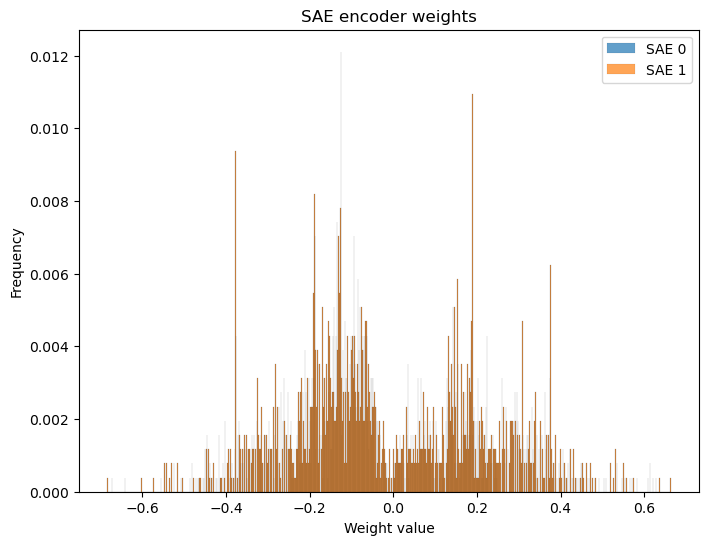

In [11]:
"""Visualize weights."""

fig, ax = plt.subplots(figsize=(8, 6))
for inst in range(n_inst):
    W_dec_flat = asnumpy(sae.W_dec[inst].float()).ravel()
    sns.histplot(W_dec_flat, bins=1000, stat="probability", alpha=0.7, label=f"SAE {inst}")
    
ax.set_title("SAE decoder weights")
ax.set_xlabel("Weight value")
ax.set_ylabel("Frequency")
ax.legend()

fig, ax = plt.subplots(figsize=(8, 6))
for inst in range(n_inst):
    W_enc_flat = asnumpy(sae.W_enc[inst].float()).ravel()
    sns.histplot(W_dec_flat, bins=1000, stat="probability", alpha=0.7, label=f"SAE {inst}")
    
ax.set_title("SAE encoder weights")
ax.set_xlabel("Weight value")
ax.set_ylabel("Frequency")
ax.legend()

SAE batch evaluation step: 100%|██████████| 18750/18750 [00:28<00:00, 655.25it/s]
/nldisco/.pixi/envs/default/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


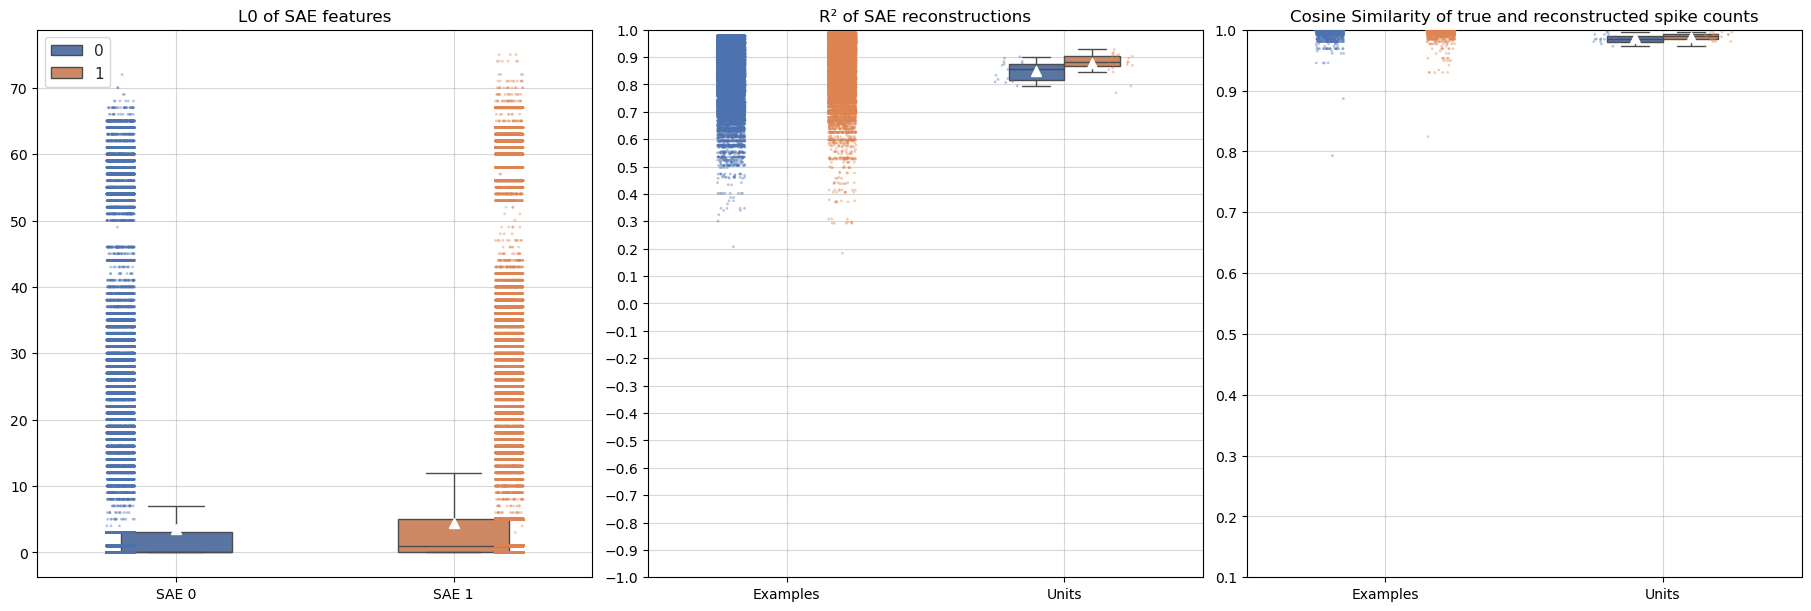

In [12]:
"""Visualize metrics over all examples and units."""

topk_acts_4d, recon_spk_cts, r2_per_unit, _, cossim_per_unit, _ = mt.eval_model(spike_cts, sae, batch_sz=batch_sz)

In [13]:
"""Calculate variance explained of summed spike counts."""

# Var explained for summed spike counts.
n_recon_examples = recon_spk_cts.shape[0]
recon_summed_spk_cts = reduce(recon_spk_cts, "example inst unit -> example inst", "sum")
actual_summed_spk_cts = reduce(spike_cts, "example unit -> example", "sum")
actual_summed_spk_cts = actual_summed_spk_cts[0:n_recon_examples]  # trim to match
for inst in range(n_inst):
    r2 = r2_score(
        asnumpy(actual_summed_spk_cts.float()), asnumpy(recon_summed_spk_cts[:, inst].float())
    )
    print(f"SAE instance {inst} R² (summed spike count over all units per example) = {r2:.3f}")

SAE instance 0 R² (summed spike count over all units per example) = 0.818
SAE instance 1 R² (summed spike count over all units per example) = 0.842


## Remove bad units and retrain

In [ ]:
#Re-train.

r2_thresh = 0.1
inst = 0
r2_per_unit = r2_per_unit[:, inst]
keep_mask = r2_per_unit > r2_thresh
print(f"frac units above {r2_thresh=}: {keep_mask.sum() / keep_mask.shape[0]:.2f}")
print(f"Number to keep: {keep_mask.sum()} / {keep_mask.shape[0]}")

# Remove units and retrain
spk_cts = spike_cts[:, keep_mask]

sae_cfg = mt.SaeConfig(
    n_input_ae=spk_cts.shape[1],
    dsae_topk_map=dsae_topk_map,
    dsae_loss_x_map=dsae_loss_x_map,
    seq_len=1,
    n_instances=n_inst,
)
sae = mt.Sae(sae_cfg).to(device)
loss_fn = mt.msle
tau = 1.0
lr = 5e-4

n_epochs = 20
batch_sz = 16
n_steps = spk_cts.shape[0] // batch_sz * n_epochs
log_freq = n_steps // n_epochs // 2
dead_neuron_window = n_steps // n_epochs // 3

data_log = mt.optimize(  # train model
    spk_cts=spk_cts,
    sae=sae,
    loss_fn=loss_fn,
    optimizer=t.optim.Adam(sae.parameters(), lr=lr),
    use_lr_sched=True,
    dead_neuron_window=dead_neuron_window,
    n_steps=n_steps,
    log_freq=log_freq,
    batch_sz=batch_sz,
    log_wandb=False,
    plot_l0=False,
    tau=tau
)

In [ ]:

file_path = "./sae_latents_Z.npy"

if os.path.exists(file_path):
    os.remove(file_path)
    print("File deleted")
else:
    print("File not found")

In [ ]:
#Re-visualize metrics over all examples and units.


topk_acts_4d, recon_spk_cts, r2_per_unit, _, cossim_per_unit, _ = mt.eval_model(spk_cts, sae, batch_sz=batch_sz)

n_recon_examples = recon_spk_cts.shape[0]
recon_summed_spk_cts = reduce(recon_spk_cts, "example inst unit -> example inst", "sum")
actual_summed_spk_cts = reduce(spk_cts, "example unit -> example", "sum")
actual_summed_spk_cts = actual_summed_spk_cts[0:n_recon_examples]  # trim to match
for inst in range(n_inst):
    r2 = r2_score(
        asnumpy(actual_summed_spk_cts.float()), asnumpy(recon_summed_spk_cts[:, inst].float())
    )
    print(f"SAE instance {inst} R² (summed spike count over all units per example) = {r2:.3f}")


## Interpret features

In [ ]:

out_dir = Path("/workspace/SAE_place_cells/")
session_id = "31-08-2025_12_47_55"  # change to your session id

load_acts = False  # if True, will load saved feature activations
save_acts = False
sae_datafile = "sae_0.csv"  # set name of data file to load (or save to)

acts_df_save_path = out_dir / f"{session_id}" / "sae_features" / sae_datafile
acts_df_save_path.parent.mkdir(parents=True, exist_ok=True)

In [ ]:
"""Create dfs of feature activations."""

if not load_acts:

    # Convert tensor to numpy array for easier handling
    acts_array = asnumpy(topk_acts_4d)

    # Create DataFrame with the data
    acts_df = pd.DataFrame({
        "example_idx": acts_array[:, 0],
        "instance_idx": acts_array[:, 1],
        "feature_idx": acts_array[:, 2],
        "activation_value": acts_array[:, 3]
    })

    # Convert appropriate cols to ints
    acts_df["example_idx"] = acts_df["example_idx"].astype(int)
    acts_df["feature_idx"] = acts_df["feature_idx"].astype(int)
    acts_df["instance_idx"] = acts_df["instance_idx"].astype(int)

    n_recon_examples = int(acts_df.iloc[-1]["example_idx"]) + 1

print(acts_df.head(5))

In [ ]:
display(acts_df)

In [ ]:
"""Compare features from ("broad" or "general") and ("specific" or "nested") levels.

last_feat_idx_general = list(dsae_topk_map.keys())[0]
first_feat_idx_specific = list(dsae_topk_map.keys())[1]

print(features_df[features_df["feature_idx"] < last_feat_idx_general]["activation_frac"].describe())
print()
print(features_df[np.logical_and(
    features_df["feature_idx"] > last_feat_idx_general,
    features_df["feature_idx"] < first_feat_idx_specific
)]["activation_frac"].describe())
print()
print(features_df[features_df["feature_idx"] > first_feat_idx_specific]["activation_frac"].describe())"""

## Hunt for features

In [ ]:
"""For a particular feature, get times it fired + stim deta at these times."""

# Inputs you already have:
# pos: shape (T,) continuous linear position
# features_df["feature_idx"]:   shape (T, F) continuous activations (or binary 0/1)
# features_df["example_idx"]:   shape (T,) time vector (optional) or assume uniform sampling dt

from scipy.ndimage import gaussian_filter1d
import os

instance_to_visualize = 0
for instance in range(instance_to_visualize, instance_to_visualize + 1):
    print("--------------------------------------------------")
    print(f"Instance {instance}:")
    features_df = acts_df[acts_df["instance_idx"] == instance].reset_index(drop=True)
    print("  feature_idx range:",  features_df["feature_idx"].min(), "-",  features_df["feature_idx"].max())
    print("  n activations:", len( features_df))
    print("  n unique features:",  features_df["feature_idx"].nunique())
    print("  n unique examples:",  features_df["example_idx"].nunique())
    print()

    # Parameters (tune as needed)
    n_bins = 10
    sigma_bins = 1.0            # smoothing sigma in bin units. Set to 0 to skip smoothing.
    min_occupancy_s = 0.2       # seconds minimum occupancy per bin; set 0 to ignore
    save_dir = "feature_ratemaps"  # set None to show inline instead of saving
    row_normalize = True        # if True, scale each feature's ratemap to [0,1] for visualization
    plot_type = "line"          # "line" or "bar" (per feature)
    figsize = (6,3)

    # -----------------------------------------------------------------------

    # Basic checks
    assert 'feature_idx' in features_df.columns and 'example_idx' in features_df.columns, \
        "features_df must contain 'feature_idx' and 'example_idx' columns."

    # If activation values exist, use them; else create implied activation_value = 1 per row (count)
    if 'activation_value' in features_df.columns:
        features_df['activation_value'] = features_df['activation_value'].astype(float)
    else:
        features_df['activation_value'] = 1.0

    # Convert pos & t to numpy
    pos = np.load("./" + folder + "/positions.npy")
    time = np.load("./" + folder + "/timestamps.npy")
    T = len(pos)
    if 'time' in globals():
        t = np.asarray(time)
        # estimate dt as median diff; if irregular sampling you might compute occupancy per-sample differently
        dt = np.median(np.diff(t))
    else:
        dt = 1.0   # assume uniform sampling; occupancy in "samples" units

    # 1) define spatial bins and occupancy
    edges = np.linspace(pos.min(), pos.max(), n_bins + 1)
    bin_idx_all = np.digitize(pos, edges) - 1
    bin_idx_all = np.clip(bin_idx_all, 0, n_bins-1)

    # occupancy in seconds per bin
    counts = np.bincount(bin_idx_all, minlength=n_bins)
    T_bins = counts * dt
    p_bins = T_bins / T_bins.sum()

    # optionally mask low-occupancy bins
    low_occ_mask = T_bins < min_occupancy_s

    # 2) Map feature activations (rows) to bins using example_idx -> pos -> bin
    # Make sure example_idx is integer and indices are within range
    features_df = features_df.copy()
    features_df['example_idx'] = features_df['example_idx'].astype(int)
    features_df = features_df[(features_df['example_idx'] >= 0) & (features_df['example_idx'] < T)].reset_index(drop=True)
    # Map example -> position bin
    features_df['bin'] = bin_idx_all[features_df['example_idx'].values]

    # 3) Aggregate activations per feature x bin
    # We compute sum of activation_value per (feature, bin). For counts-based data this is just counts.
    agg = features_df.groupby(['feature_idx', 'bin'])['activation_value'].sum().unstack(fill_value=0)  # shape: (n_features, n_bins)
    # ensure all bins exist as columns
    agg = agg.reindex(columns=np.arange(n_bins), fill_value=0)

    # 4) Convert aggregated activations to occupancy-normalized ratemap
    # rate = total_activation_in_bin / occupancy_seconds_in_bin
    # If dt units are samples, this gives activations per second if activation_value counted spikes per sample
    occ = T_bins.copy().astype(float)
    occ[occ == 0] = np.nan  # avoid division by zero; we'll mask these later
    ratemap = agg.values / occ[np.newaxis, :]   # shape (n_features, n_bins)

    # 5) smoothing (optional)
    if sigma_bins > 0:
        # for a linear track use mode='constant' to avoid wrap-around
        ratemap_sm = gaussian_filter1d(ratemap, sigma=sigma_bins, axis=1, mode='constant')
    else:
        ratemap_sm = ratemap

    # 6) prepare plotting folder
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # Function to compute a simple selectivity metric (peak / mean) for ordering
    peak_over_mean = (ratemap_sm.max(axis=1) + 1e-12) / (np.nanmean(ratemap_sm, axis=1) + 1e-12)
    # order features by peak bin (so place-like fields line up) or by peak_over_mean
    peak_bin = np.nanargmax(ratemap_sm, axis=1)
    order = np.argsort(peak_bin)  # primary sort by peak location
    # alternative: order = np.argsort(-peak_over_mean)  # by selectivity

    # 7) iterate and plot each feature's ratemap
    import math
    from matplotlib import gridspec

    feature_ids = agg.index.values
    for i_feat in order:
        feat = feature_ids[i_feat]  # actual feature_idx label (could be non-contiguous)
        row = ratemap_sm[i_feat, :].copy()
        # mask low-occupancy bins for plotting clarity
        row_vis = row.copy()
        row_vis[low_occ_mask] = np.nan

        if row_normalize:
            mx = np.nanmax(row_vis)
            if np.isfinite(mx) and mx > 0:
                row_vis = row_vis / mx

        # build plot
        fig, ax = plt.subplots(figsize=figsize)
        bins_centers = (edges[:-1] + edges[1:]) / 2.0

        if plot_type == "line":
            ax.plot(bins_centers, row_vis, marker='o', linestyle='-')
            ax.set_ylim(0, 1.05 if row_normalize else None)
        else:  # bar
            ax.bar(bins_centers, row_vis, width=(edges[1]-edges[0])*0.9, align='center')
            if row_normalize:
                ax.set_ylim(0,1.05)

        ax.set_xlabel("Position along track (bin centers)")
        ax.set_ylabel("Normalized activation" if row_normalize else "Activation / sec")
        ax.set_title(f"Feature {feat} — peak_bin={peak_bin[i_feat]}, peak_val={ratemap_sm[i_feat].max():.3g}")
        # optionally annotate occupancy under plot
        ax2 = ax.twinx()
        ax2.plot(bins_centers, T_bins, color='r', alpha=0.2)
        ax2.set_ylabel("Occupancy (s)", alpha=0.5)
        ax2.set_ylim(0, max(T_bins)*1.1)

        plt.tight_layout()
        plt.show()

        if save_dir:
            fname = os.path.join(save_dir, f"ratemap_feature_{feat}.png")
            fig.savefig(fname, dpi=150)
            plt.close(fig)

    # 8) Summary DF of metrics (optional)
    metrics_df = pd.DataFrame({
        "feature_idx": feature_ids,
        "peak_bin": peak_bin,
        "peak_value": ratemap_sm.max(axis=1),
        "mean_value": np.nanmean(ratemap_sm, axis=1),
        "selectivity": peak_over_mean
    })
    metrics_df = metrics_df.sort_values(['peak_bin', 'selectivity'], ascending=[True, False]).reset_index(drop=True)
    metrics_df.to_csv(os.path.join(save_dir, "feature_ratemap_metrics.csv"), index=False)
    print("Done. Ratemaps saved to:", save_dir)



## Validate results with PCA

Explained variance ratio (PC1..): [0.0659 0.0574 0.0515 0.051  0.0508 0.0506]


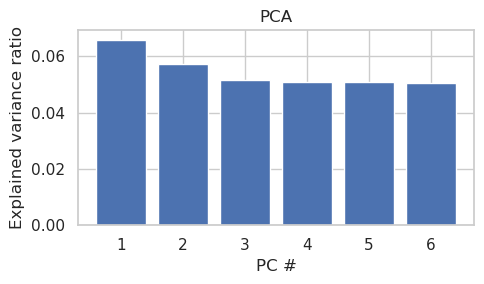

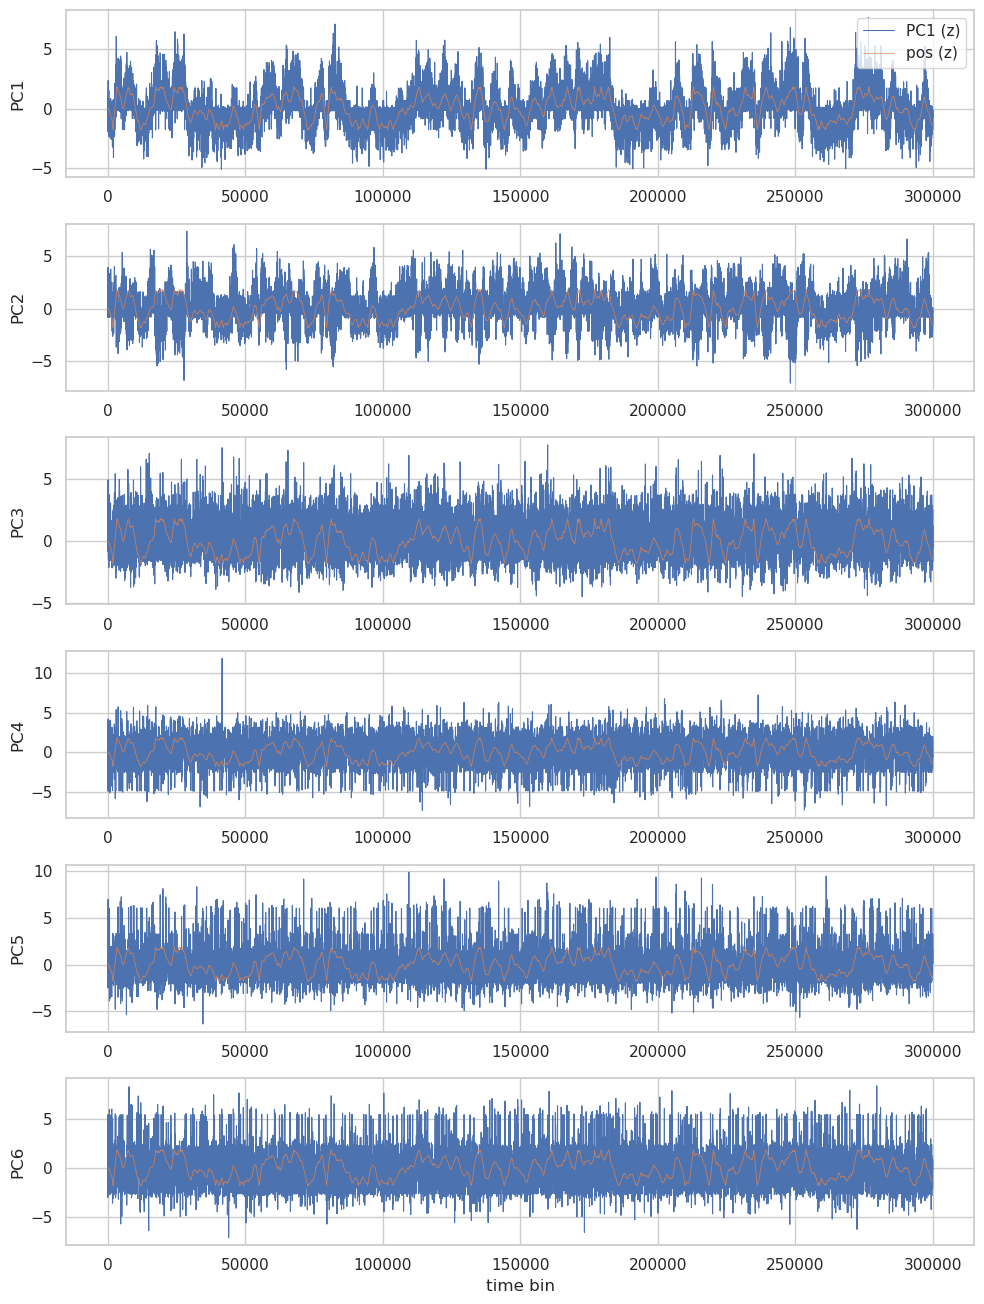

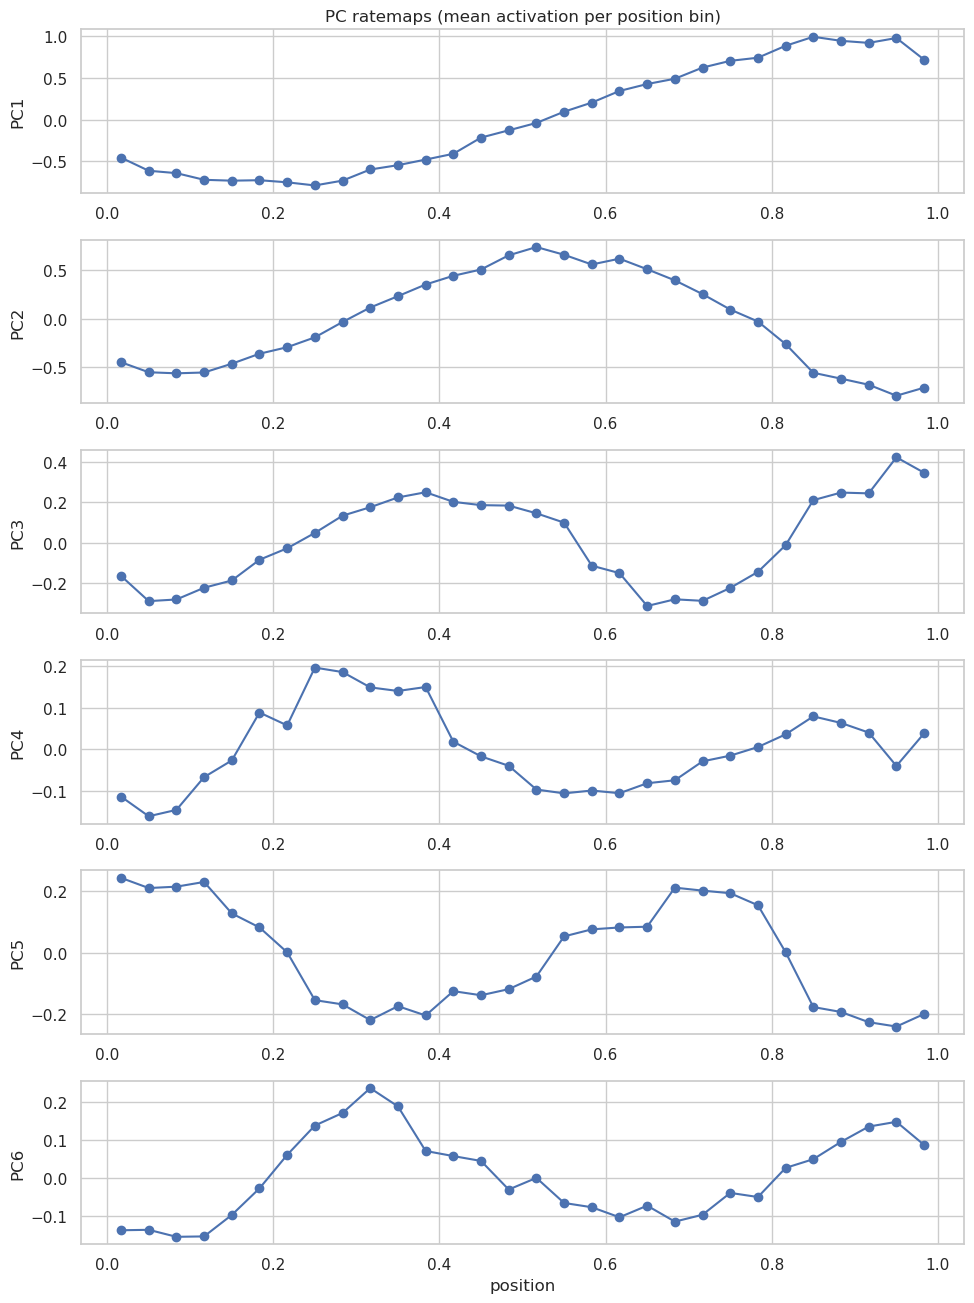

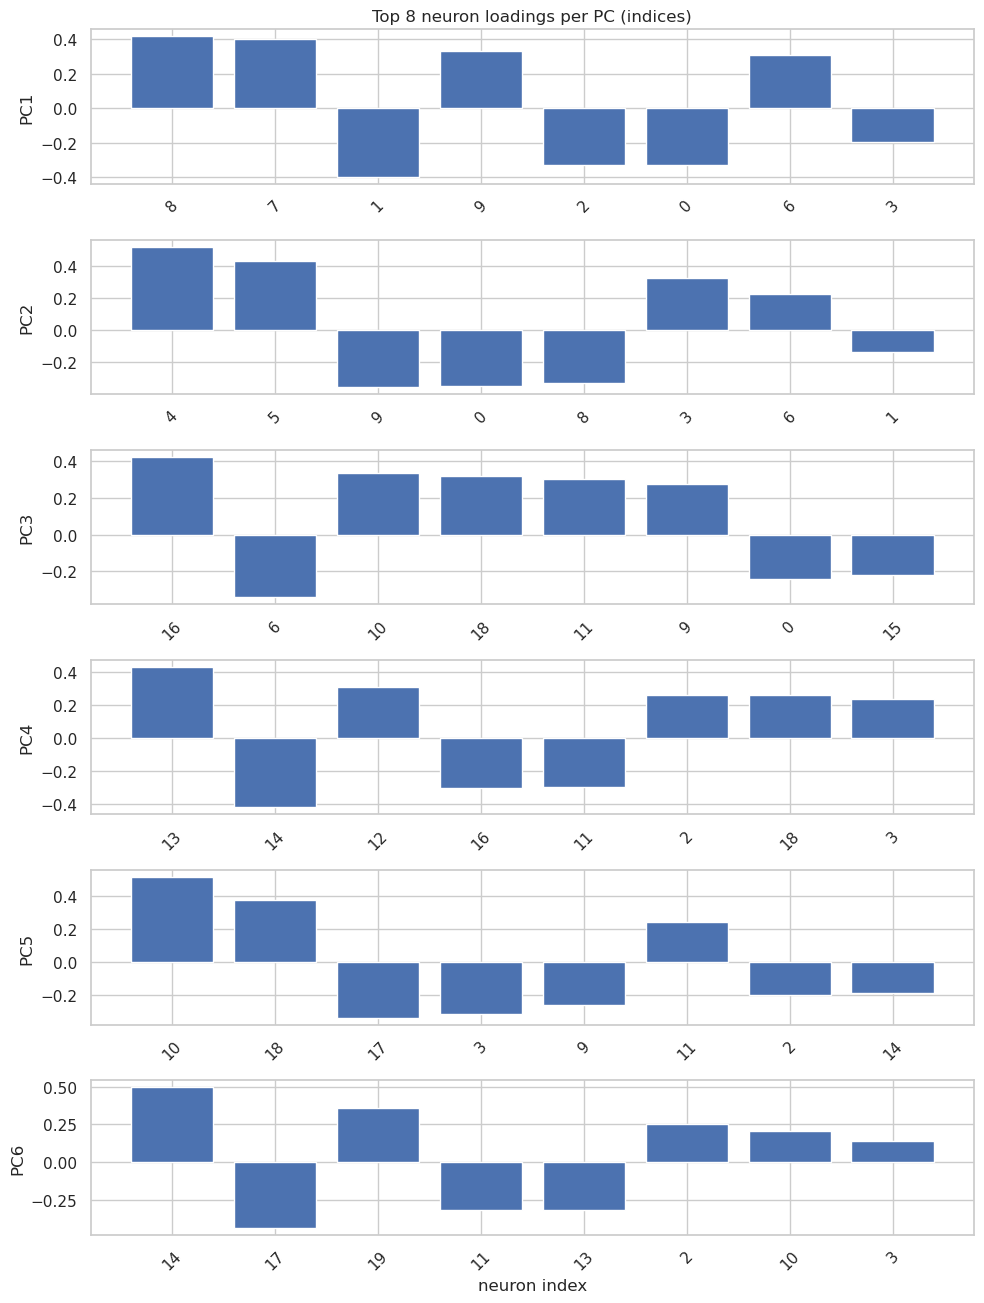

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ---------- USER: ensure spike_cts (T, N) and pos (T,) are in scope ----------
# Example:
# spike_cts = np.load("spike_cts.npy")   # shape (T, N)
# pos = np.load("pos.npy")               # shape (T,)
# ---------------------------------------------------------------------------

def simple_pca_inspect(spike_cts, pos, n_components=6, n_pos_bins=30, smoothing_sigma=None):
    """
    Minimal PCA + plots for interpretation.
    Inputs:
      - spike_cts: (T, N) array of spike counts/rates
      - pos: (T,) continuous position along track
      - n_components: number of PCs to compute and plot
      - n_pos_bins: bins for ratemap plots
      - smoothing_sigma: optional gaussian smoothing (float); None => no smoothing
    """
    # --- basic checks & preprocessing ---
    spike_cts = spike_cts.detach().cpu().to(t.float32).numpy()
    #pos = pos.detach().cpu().numpy()
    X = np.asarray(spike_cts).astype(float)
    pos = np.asarray(pos).ravel()
    if X.shape[0] != pos.shape[0]:
        raise ValueError("Time dimension mismatch: spike_cts.shape[0] != pos.shape[0]")
    # optional smoothing (along time axis)
    if smoothing_sigma is not None and smoothing_sigma > 0:
        from scipy.ndimage import gaussian_filter1d
        X = gaussian_filter1d(X, sigma=smoothing_sigma, axis=0, mode='reflect')
    # quick variance-stabilizing transform (optional but often useful)
    X = np.sqrt(X + 3./8.)
    # per-neuron z-score
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

    # --- PCA ---
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(X)          # (T, n_components)
    comps = pca.components_             # (n_components, N)
    explained = pca.explained_variance_ratio_

    print("Explained variance ratio (PC1..):", np.round(explained, 4))

    # --- plotting ---
    time = np.arange(X.shape[0])
    pos_z = (pos - pos.mean()) / (pos.std() + 1e-8)

    # 1) explained variance
    plt.figure(figsize=(5,3))
    plt.bar(np.arange(1, len(explained)+1), explained)
    plt.xlabel("PC #"); plt.ylabel("Explained variance ratio"); plt.title("PCA")
    plt.tight_layout(); plt.show()

    # 2) top K PC timecourses vs position (z-scored) for visual comparison
    K = min(n_components, pcs.shape[1])
    plt.figure(figsize=(10, 2.2 * K))
    for i in range(K):
        ax = plt.subplot(K, 1, i+1)
        pc_z = (pcs[:, i] - pcs[:, i].mean()) / (pcs[:, i].std() + 1e-8)
        ax.plot(time, pc_z, label=f"PC{i+1} (z)", linewidth=0.8)
        ax.plot(time, pos_z, label="pos (z)", linewidth=0.6, alpha=0.8)
        ax.set_ylabel(f"PC{i+1}")
        if i == 0:
            ax.legend(loc="upper right")
    plt.xlabel("time bin"); plt.tight_layout(); plt.show()

    # 3) ratemaps: mean PC activation per position bin
    bins = np.linspace(pos.min(), pos.max(), n_pos_bins+1)
    bin_idx = np.digitize(pos, bins) - 1
    bin_idx[bin_idx == n_pos_bins] = n_pos_bins - 1
    centers = 0.5 * (bins[:-1] + bins[1:])
    plt.figure(figsize=(10, 2.2 * K))
    for i in range(K):
        mean_by_bin = np.array([pcs[bin_idx == b, i].mean() if np.any(bin_idx==b) else np.nan
                                for b in range(n_pos_bins)])
        ax = plt.subplot(K, 1, i+1)
        ax.plot(centers, mean_by_bin, marker='o')
        ax.set_ylabel(f"PC{i+1}")
        if i == 0:
            ax.set_title("PC ratemaps (mean activation per position bin)")
    plt.xlabel("position"); plt.tight_layout(); plt.show()

    # 4) loadings: show top contributing neurons per PC
    #    we'll plot the absolute weights and list top-5 neuron indices per PC
    topk = 8
    plt.figure(figsize=(10, 2.2 * K))
    for i in range(K):
        w = comps[i]   # length N
        idx = np.argsort(np.abs(w))[::-1][:topk]
        ax = plt.subplot(K, 1, i+1)
        ax.bar(np.arange(topk), w[idx])
        ax.set_xticks(np.arange(topk))
        ax.set_xticklabels([str(j) for j in idx], rotation=45)
        ax.set_ylabel(f"PC{i+1}")
        if i == 0:
            ax.set_title(f"Top {topk} neuron loadings per PC (indices)")
    plt.xlabel("neuron index"); plt.tight_layout(); plt.show()

    # return objects for further inspection if needed
    return {"pca": pca, "pcs": pcs, "components": comps, "explained": explained, "pos_bins": centers}

# -------------------------
# Example usage 
# -------------------------
pos = np.load("./" + folder + "/positions.npy")
time = np.load("./" + folder + "/timestamps.npy")
res = simple_pca_inspect(spike_cts, pos, n_components=6, n_pos_bins=30, smoothing_sigma=3)


Median SNR: 0.001797489712744094


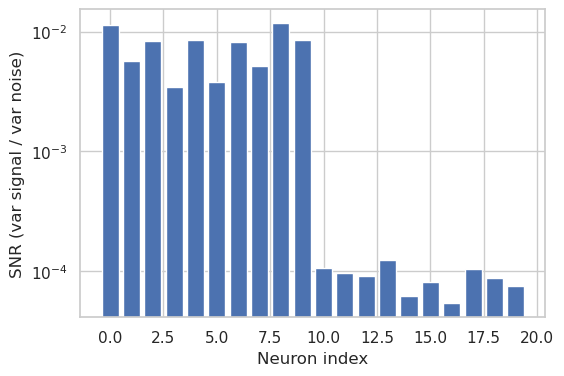

In [15]:
# Check noise-to-signal ratio of spike data

# X: (T, N) spike counts, pos: (T,)
def per_neuron_snr(X, pos, n_pos_bins=30):
    # estimate signal as variance of neuron's mean firing across position bins
    bins = np.linspace(pos.min(), pos.max(), n_pos_bins+1)
    bin_idx = np.digitize(pos, bins) - 1
    bin_idx[bin_idx == n_pos_bins] = n_pos_bins-1
    N = X.shape[1]
    signal_var = np.zeros(N)
    noise_var  = np.zeros(N)
    for i in range(N):
        # mean rate per position bin
        means = [X[bin_idx==b, i].mean() if (bin_idx==b).any() else 0.0 for b in range(n_pos_bins)]
        signal_var[i] = np.var(means)
        # residual variance: average within-bin variance
        within = [X[bin_idx==b, i].var() if (bin_idx==b).any() else 0.0 for b in range(n_pos_bins)]
        noise_var[i] = np.mean(within)
    # SNR estimate = signal variance / noise variance (handle zero)
    snr = signal_var / (noise_var + 1e-8)
    return snr, signal_var, noise_var

spike_array = spike_cts.detach().cpu().to(t.float32).numpy()
snr, sig, nvar = per_neuron_snr(spike_array, pos)
print("Median SNR:", np.median(snr))

plt.figure(figsize=(6,4))
plt.bar(np.arange(len(snr)), snr)
plt.yscale('log')
plt.xlabel("Neuron index")
plt.ylabel("SNR (var signal / var noise)")
plt.show()


## Linearly decode position based on SAE features vs PC from PCA

Shuffle baseline R^2 (mean ± std): -2.9680586066486164e-05 1.9761711624538247e-05
SAE top-1 CV R2: 4.5999429074794485e-05 ± 8.270355736123362e-05
PCA top-1 CV R2: 0.27127698748783685 ± 0.0016424955207674018
Spike top-10 CV R2: 0.03191406532394301 ± 0.0007609685320333403


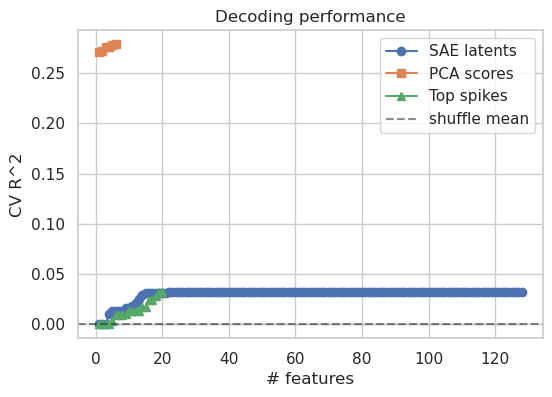

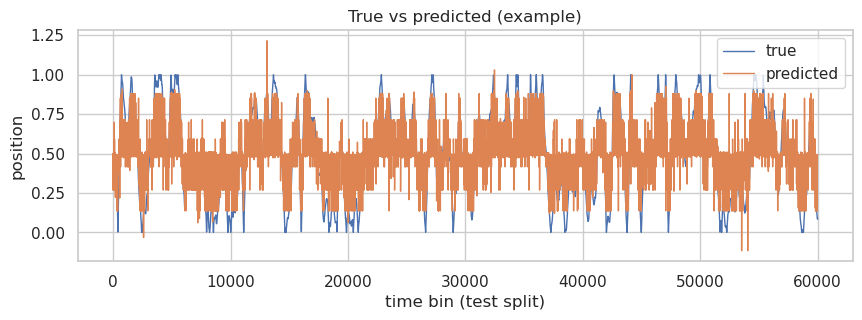

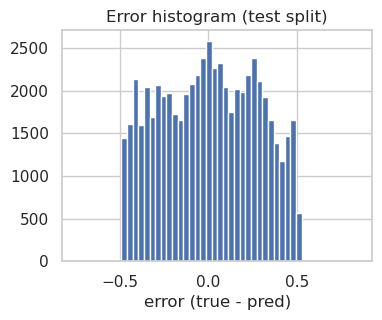

In [16]:
# ---------------------------
# Inputs you must have in scope
# ---------------------------
# Z: numpy array (T, L)  -> SAE latent timecourses (rows aligned with pos)
# pos: numpy array (T,)  -> continuous position along track
# spike_cts: numpy array (T, N) -> optional baseline
# pcs: numpy array (T, P) -> optional PCA scores (if you ran PCA), else compute below
# ---------------------------
from sklearn.preprocessing import StandardScaler

def cv_decode(X_features, y, n_splits=5, alpha=1.0):
    """Return mean and std of CV R^2 and RMSE for Ridge(alpha)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    r2s = []
    rmses = []
    for tr, te in kf.split(X_features):
        model = Ridge(alpha=alpha)
        model.fit(X_features[tr], y[tr])
        yhat = model.predict(X_features[te])
        r2s.append(r2_score(y[te], yhat))
        rmses.append(np.sqrt(mean_squared_error(y[te], yhat)))
    return np.mean(r2s), np.std(r2s), np.mean(rmses), np.std(rmses)

def prepare_Z(Z):
    """
    Normalize shape to (T, D) or (T, n_inst, D) handling common saved formats.
    Returns Z_use (T, D) by default (taking instance 0 if multiple instances),
    and a dict describing alternatives.
    """
    info = {}
    if Z.ndim == 1:
        Z = Z.reshape(-1, 1)
    if Z.ndim == 2:
        # (T, D) already
        Z_use = Z
        info['mode'] = 'single'
    elif Z.ndim == 3:
        # (T, n_inst, D) or (T, D, n_inst) -- assume (T, n_inst, D)
        if Z.shape[1] <= 8 and Z.shape[2] > Z.shape[1]:  # heuristic
            # (T, n_inst, D): provide both single instance and concatenated
            inst0 = Z[:, 0, :]
            Z_concat = Z.reshape(Z.shape[0], -1)  # concat across instances
            Z_use = inst0
            info['mode'] = 'multi_instance'
            info['Z_concat'] = Z_concat
            info['n_inst'] = Z.shape[1]
        else:
            # fallback: squeeze middle
            Z_use = Z.squeeze(1)
            info['mode'] = 'squeezed'
    else:
        raise ValueError(f"Unexpected Z.ndim={Z.ndim}. Expected 2 or 3.")

    return Z_use.astype(np.float32), info

def decode_vs_features(Z_raw, pos, spike_cts=None, pcs=None, maxK=None, n_splits=5):
    """
    Compute CV decoding R^2 and RMSE as a function of number of features for:
      - SAE latents (Z)
      - PCA scores (pcs) if provided
      - raw spikes (spike_cts) if provided (typically use top-N by variance or all)
    Returns results dict and also prints summary.
    """
    T = pos.shape[0]
    results = {}

    # SAE latents
    Z_out = prepare_Z(Z_raw)
    Z = Z_out[0]
    L = Z.shape[1]
    maxK_z = min(L, maxK) if maxK is not None else L
    r2_z = []; r2_z_std = []; rmse_z = []; rmse_z_std = []
    for K in range(1, maxK_z + 1):
        r_mean, r_std, rm, rmsd = cv_decode(Z[:, :K], pos, n_splits=n_splits)
        r2_z.append(r_mean); r2_z_std.append(r_std)
        rmse_z.append(rm); rmse_z_std.append(rmsd)
    results['sae'] = dict(Ks=list(range(1, maxK_z+1)), r2=np.array(r2_z), r2_std=np.array(r2_z_std),
                          rmse=np.array(rmse_z), rmse_std=np.array(rmse_z_std))

    # PCA baseline
    if pcs is None and spike_cts is not None:
        # quick PCA to get pcs if not provided
        from sklearn.decomposition import PCA
        pca = PCA(n_components=min(spike_cts.shape[1], 50))
        pcs = pca.fit_transform((np.sqrt(spike_cts + 3/8.0) - np.sqrt(spike_cts + 3/8.0).mean(axis=0)) / (np.sqrt(spike_cts + 3/8.0).std(axis=0)+1e-8))

    if pcs is not None:
        P = pcs.shape[1]
        maxK_p = min(P, maxK) if maxK is not None else P
        r2_p = []; r2_p_std = []; rmse_p = []; rmse_p_std = []
        for K in range(1, maxK_p + 1):
            r_mean, r_std, rm, rmsd = cv_decode(pcs[:, :K], pos, n_splits=n_splits)
            r2_p.append(r_mean); r2_p_std.append(r_std)
            rmse_p.append(rm); rmse_p_std.append(rmsd)
        results['pca'] = dict(Ks=list(range(1, maxK_p+1)), r2=np.array(r2_p), r2_std=np.array(r2_p_std),
                              rmse=np.array(rmse_p), rmse_std=np.array(rmse_p_std))

    # Raw spikes baseline (z-scored per neuron)
    if spike_cts is not None:
        # transfer spike_cts to cpu and then to numpy
        spike_cts = spike_cts.detach().cpu().to(t.float32).numpy()
        Xz = (np.sqrt(spike_cts + 3/8.0) - np.sqrt(spike_cts + 3/8.0).mean(axis=0)) / (np.sqrt(spike_cts + 3/8.0).std(axis=0)+1e-8)
        N = Xz.shape[1]
        maxK_s = min(N, maxK) if maxK is not None else min(50, N)
        # choose top features by variance for efficiency
        var_idx = np.argsort(Xz.var(axis=0))[::-1][:maxK_s]
        r2_s = []; r2_s_std = []; rmse_s = []; rmse_s_std = []
        for K in range(1, maxK_s + 1):
            cols = var_idx[:K]
            r_mean, r_std, rm, rmsd = cv_decode(Xz[:, cols], pos, n_splits=n_splits)
            r2_s.append(r_mean); r2_s_std.append(r_std)
            rmse_s.append(rm); rmse_s_std.append(rmsd)
        results['spikes'] = dict(Ks=list(range(1, maxK_s+1)), r2=np.array(r2_s), r2_std=np.array(r2_s_std),
                                rmse=np.array(rmse_s), rmse_std=np.array(rmse_s_std))

    return results

def shuffle_baseline(X_features, pos, n_shuffles=50, n_splits=5):
    """Shuffle pos and compute CV R^2 distribution to get chance level."""
    r2s = []
    rng = np.random.RandomState(0)
    for s in range(n_shuffles):
        pos_s = rng.permutation(pos)
        r_mean, r_std, _, _ = cv_decode(X_features, pos_s, n_splits=n_splits)
        r2s.append(r_mean)
    return np.mean(r2s), np.std(r2s)

# ---------------------------
# Example usage:
# ---------------------------
# Compute results (choose maxK to compare up to)
Z_out = np.load("sae_latents_Z.npy")
pcs =  res['pcs']
results = decode_vs_features(Z_out, pos, spike_cts=spike_cts if 'spike_cts' in globals() else None,
                             pcs=pcs if 'pcs' in globals() else None, maxK=128, n_splits=5)

Z = Z_out[:,0,:]
# Shuffle baseline for SAE top-K=1
sae_top1 = Z[:, :1]
shuffle_mean, shuffle_std = shuffle_baseline(sae_top1, pos, n_shuffles=100, n_splits=5)
print("Shuffle baseline R^2 (mean ± std):", shuffle_mean, shuffle_std)

# Print numeric summary
print("SAE top-1 CV R2:", results['sae']['r2'][0], "±", results['sae']['r2_std'][0])
if 'pca' in results: print("PCA top-1 CV R2:", results['pca']['r2'][0], "±", results['pca']['r2_std'][0])
if 'spikes' in results: print("Spike top-10 CV R2:", results['spikes']['r2'][-1], "±", results['spikes']['r2_std'][-1])

# ---------------------------
# Plots
# ---------------------------
# 1) R^2 vs #features
plt.figure(figsize=(6,4))
plt.plot(results['sae']['Ks'], results['sae']['r2'], label='SAE latents', marker='o')
if 'pca' in results: plt.plot(results['pca']['Ks'], results['pca']['r2'], label='PCA scores', marker='s')
if 'spikes' in results: plt.plot(results['spikes']['Ks'], results['spikes']['r2'], label='Top spikes', marker='^')
plt.axhline(shuffle_mean, color='k', linestyle='--', alpha=0.5, label='shuffle mean')
plt.fill_between(results['sae']['Ks'], shuffle_mean-shuffle_std, shuffle_mean+shuffle_std, color='k', alpha=0.1)
plt.xlabel("# features"); plt.ylabel("CV R^2"); plt.legend(); plt.title("Decoding performance")
plt.show()

# 2) Example true vs predicted trajectory (use all latents)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
train_idx, test_idx = next(kf.split(Z))
clf = Ridge(alpha=1.0).fit(Z[train_idx], pos[train_idx])
pos_hat = clf.predict(Z[test_idx])
plt.figure(figsize=(10,3))
plt.plot(pos[test_idx], label='true', lw=1)
plt.plot(pos_hat, label='predicted', lw=1)
plt.legend(); plt.xlabel("time bin (test split)"); plt.ylabel("position"); plt.title("True vs predicted (example)")
plt.show()

# 3) Error histogram
err = pos[test_idx] - pos_hat
plt.figure(figsize=(4,3))
plt.hist(err, bins=50)
plt.xlabel("error (true - pred)"); plt.title("Error histogram (test split)")
plt.show()


In [ ]:

## Make boxplot of decoding error

def ensure_numpy(arr):
    try:
        import torch
        if isinstance(arr, torch.Tensor):
            arr = arr.detach().cpu().numpy()
    except Exception:
        pass
    arr = np.asarray(arr)
    # convert float16/bfloat to float32 if present
    if arr.dtype == np.float16 or str(arr.dtype).lower().startswith("bfloat"):
        arr = arr.astype(np.float32)
    return arr

def cv_ridge_rmse_per_fold(X, y, n_splits=5, alpha=1.0, random_state=0):
    """Return list of RMSE values (one per CV fold)."""
    X = ensure_numpy(X)
    y = np.asarray(y).ravel()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rmses = []
    for tr, te in kf.split(X):
        scaler = StandardScaler().fit(X[tr])
        Xtr = scaler.transform(X[tr])
        Xte = scaler.transform(X[te])
        model = Ridge(alpha=alpha)
        model.fit(Xtr, y[tr])
        yhat = model.predict(Xte)
        rmses.append(np.sqrt(mean_squared_error(y[te], yhat)))
    return rmses

# K list: use results['sae']['Ks'] if available else default
if isinstance(results, dict) and 'sae' in results and 'Ks' in results['sae']:
    K_LIST = list(results['sae']['Ks'])
else:
    # fallback ks
    K_LIST = [1,2,3,5,10]

n_splits = 5
alpha = 1.0

# ---------- compute per-fold RMSEs for each K ----------
sae_rmses_per_K = {}
pca_rmses_per_K = {}

# get pcs: prefer pcs variable or results['pca']['pcs'] or compute from spike_cts if available
pcs_arr = None
if 'pcs' in globals():
    pcs_arr = pcs
elif isinstance(results, dict) and 'pca' in results and isinstance(results['pca'], dict) and 'pcs' in results['pca']:
    pcs_arr = results['pca']['pcs']
elif 'spike_cts' in globals():
    # quick PCA fallback if required (limited components)
    from sklearn.decomposition import PCA
    Xtmp = ensure_numpy(spike_cts)
    Xtmp = np.sqrt(Xtmp + 3./8.)
    Xtmp = (Xtmp - Xtmp.mean(axis=0)) / (Xtmp.std(axis=0) + 1e-8)
    pca = PCA(n_components=min(50, Xtmp.shape[1]))
    pcs_arr = pca.fit_transform(Xtmp)
else:
    pcs_arr = None
    print("No PCA scores available; PCA baseline will be skipped.")

for K in K_LIST:
    # SAE latents
    if K <= Z.shape[1]:
        sae_rmses_per_K[K] = cv_ridge_rmse_per_fold(Z[:, :K], pos, n_splits=n_splits, alpha=alpha)
    else:
        sae_rmses_per_K[K] = [np.nan]*n_splits

    # PCA baseline
    if pcs_arr is not None and K <= pcs_arr.shape[1]:
        pca_rmses_per_K[K] = cv_ridge_rmse_per_fold(pcs_arr[:, :K], pos, n_splits=n_splits, alpha=alpha)
    else:
        pca_rmses_per_K[K] = [np.nan]*n_splits

# ---------- make side-by-side boxplot ----------
fig, ax = plt.subplots(figsize=(10,5))

boxes = []
positions = []
labels = []
step = 3  # spacing between groups
width = 0.9

for i, K in enumerate(K_LIST):
    pos_center = i * step
    pos_pca = pos_center - 0.6
    pos_sae = pos_center + 0.6

    boxes.append((pca_rmses_per_K[K], pos_pca, 'PCA'))
    boxes.append((sae_rmses_per_K[K], pos_sae, 'SAE'))
    positions.extend([pos_pca, pos_sae])
    labels.extend([f"PCA K={K}", f"SAE K={K}"])

# extract data for plotting in the same order
data = [b[0] for b in boxes]
plot_pos = [b[1] for b in boxes]
bp = ax.boxplot(data, positions=plot_pos, widths=1.0, patch_artist=True, notch=True)

# color styling
for patch, meta in zip(bp['boxes'], labels):
    if meta.startswith("PCA"):
        patch.set_facecolor("#6baed6")
    else:
        patch.set_facecolor("#fd8d3c")

# x ticks
mid_positions = []
xticklabels = []
for i, K in enumerate(K_LIST):
    mid_positions.append(i * step)
    xticklabels.append(f"K={K}")
ax.set_xticks(mid_positions)
ax.set_xticklabels(xticklabels)
ax.set_ylabel("RMSE (position units)")
ax.set_title("Decoding RMSE per CV fold: PCA vs SAE latents")
ax.grid(axis='y', alpha=0.3)

# legend
import matplotlib.patches as mpatches
p1 = mpatches.Patch(color="#6baed6", label="PCA")
p2 = mpatches.Patch(color="#fd8d3c", label="SAE")
ax.legend(handles=[p1,p2], loc='upper right')

plt.tight_layout()
plt.show()

# ---------- print numeric summary ----------
print("Summary RMSE (mean ± std over folds) per K")
for K in K_LIST:
    s = np.array(sae_rmses_per_K[K], dtype=np.float32)
    p = np.array(pca_rmses_per_K.get(K, [np.nan]*len(s)), dtype=np.float32)
    print(f"K={K:2d} | SAE RMSE = {np.nanmean(s):.4f} ± {np.nanstd(s):.4f}  |  PCA RMSE = {np.nanmean(p):.4f} ± {np.nanstd(p):.4f}")
